# Variable-mean noise: LN models across a luminance step

**The experiment.** `VariableMeanNoise` delivers Gaussian noise of constant contrast **through
an LED** while the mean light level steps periodically. One epoch therefore contains steps in
both directions, and the question is how the cell's linear-nonlinear model changes as it adapts
to each new mean.

The protocol lives in two packages —
`edu.washington.riekelab.rieke.protocols.VariableMeanNoise` and
`edu.washington.riekelab.turner.protocols.VariableMeanNoise` — and they are the same protocol:
the recorded epoch parameters are identical, verified against the stored epochs rather than
assumed. Both are searched together and `protocol_name` says which one a block came from.


Model fitting is **cascadegraph**, vendored at `retinanalysis.utils.cascadegraph` — the Python
port of the library the MATLAB used. Nothing here reimplements a filter or a sigmoid.

In [1]:
import contextlib
import io
import json
import sys
import time
from pathlib import Path

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        f'This notebook requires the retinanalysis Python 3.11 kernel; '
        f'got Python {sys.version.split()[0]} at {sys.executable}')
import_started = time.perf_counter()

import numpy as np
import pandas as pd
from IPython.display import display

import retinanalysis as ra
from retinanalysis.SCutils import explore as sc

# The analysis module sits beside this notebook: it is specific to this project.
sys.path.insert(0, str(Path.cwd()))
import variable_mean_noise as vmn

print(f'Python {sys.version.split()[0]} | {sys.executable}')
print(f'Imports ready in {time.perf_counter() - import_started:.2f} s')

Python 3.11.13 | /Users/chrischen/opt/anaconda3/envs/retinanalysis/bin/python
Imports ready in 0.70 s


## 1. Find experiment dates and cells

Discovery over both package copies of the protocol. A block is kept only if it can answer the
question this protocol asks:

- **`stimTime` ≥ 30 s** — the mean steps part-way through, so a short epoch has no post-step
  stretch to fit. The protocol's default is 600 ms and most recorded blocks are short runs.
- **primate ganglion cells only** — ON/OFF parasol, ON/OFF midget, AII. Cones, horizontals and
  unlabelled cells are a different experiment.
- **more than one light mean** — a cell that only ever saw one mean has no step to measure.
- **one noise contrast** — a filter pooled across contrasts describes neither.

`cell_index` is the handle to copy into §2, so the cell label never has to be typed. Rows are
grouped by experiment.

`n_extracellular` / `n_exc` / `n_inh` come from the recording-type check below, and are the
column that says whether a cell is worth opening and in which mode. **One cell often has blocks
of more than one type** — held cell-attached for one and whole-cell for the next — and those are
never fitted together.

### 1a. Recording type per block

These blocks carry no `onlineAnalysis`, so the amplifier decides. The epoch group's
`recordingTechnique` settles most of them; where it does not, series resistance above zero means
whole-cell with the polarity from the sign of the current (inward is `exc`, outward `inh`), and a
reading of exactly zero is confirmed against the trace, since it also happens when compensation
was never run.

Resolving a block that needs its trace is seconds per block, so this is **cached** to
`block_modes.csv` beside the notebook. Set `REFRESH_MODE_CACHE = True` to rebuild it (a few
minutes over ~400 blocks); otherwise it is read from disk.

In [2]:
REFRESH_MODE_CACHE = False

protocol_blocks = vmn.find_blocks(show=True, height=0)

if REFRESH_MODE_CACHE or not vmn.MODE_CACHE_PATH.exists():
    print(f'\nbuilding {vmn.MODE_CACHE_PATH.name} — a few minutes ...')
    rows = []
    for n, block_id in enumerate(protocol_blocks.block_id, 1):
        exp_name = protocol_blocks.loc[
            protocol_blocks.block_id.eq(block_id), 'exp_name'].iloc[0]
        rows.append(dict(exp_name=exp_name, block_id=int(block_id),
                         n_epochs=len(vmn.epoch_parameters(int(block_id))),
                         **vmn.resolve_block_mode(exp_name, int(block_id))))
        if n % 50 == 0:
            print(f'  {n}/{len(protocol_blocks)}')
    pd.DataFrame(rows).to_csv(vmn.MODE_CACHE_PATH, index=False)

block_modes = vmn.load_block_modes()
print(f'\nrecording types over {len(block_modes)} cached blocks:')
print(block_modes.rec_type.value_counts(dropna=False).to_string())

373 blocks | 46 experiments | 182 cells
  dropped 1227 block(s) with stimTime < 30 s
  dropped 120 block(s) on non-primate-RGC cell types
  by protocol: edu.washington.riekelab.rieke.protocols.VariableMeanNoise 262, edu.washington.riekelab.turner.protocols.VariableMeanNoise 111


exp_name,cell_label,cell_type_short,block_id,stim_seconds,led,ndfs,frequencyCutoff,numberOfFilters,Contrast,n_epochs,protocol_name
2020-06-11_B,Cell10,ON-parasol,30238,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,14,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell11,ON-midget,30209,60.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,2,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell11,ON-midget,30210,60.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,20,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell12,OFF-parasol,30188,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,15,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell13,ON-parasol,30174,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,19,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell13,ON-parasol,30177,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,6,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell14,ON-parasol,30216,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,14,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell14,ON-parasol,30218,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,27,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-16_B,Cell3,ON-parasol,30318,60.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,10,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-16_B,Cell3,ON-parasol,30319,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,11,edu.washington.riekelab.rieke.protocols.VariableMeanNoise



recording types over 493 cached blocks:
rec_type
extracellular    320
exc              131
none              34
inh                8


In [3]:
protocol_cells = vmn.find_protocol_cells(protocol_blocks, modes=block_modes,
                                        show=True, height=460)

125 cells across 35 experiments
  dropped 54 cell(s) that ran only one light mean
  dropped 3 cell(s) that ran more than one contrast


exp_name,cell_index,cell_label,cell_type,n_extracellular,n_exc,n_inh,light_means,light_contrast,stim_seconds,led
2020-06-11_B,0,Cell10,ON-parasol,0,14,0,"0.3, 3",0.5,30,UV LED
,1,Cell11,ON-midget,0,22,0,"0.3, 3",0.5,60,UV LED
,2,Cell12,OFF-parasol,15,0,0,"0.3, 3",0.5,30,UV LED
,3,Cell13,ON-parasol,19,6,0,"0.3, 3",0.5,30,UV LED
,4,Cell14,ON-parasol,14,27,0,"0.3, 3",0.5,30,UV LED
2020-06-16_B,5,Cell3,ON-parasol,21,53,0,"0.08, 0.3, 0.8, 3",0.5,"30, 60",UV LED
2020-06-23_B,6,Cell10,OFF-parasol,10,0,0,"0.3, 3",0.5,30,UV LED
,7,Cell8,ON-midget,20,0,0,"0.1, 1",0.5,30,UV LED
2021-02-01_B,8,cell1,ON-parasol,62,0,0,"0.05, 0.08, 0.5, 1, 5",0.5,30,UV LED
,9,cell2,ON-midget,31,0,0,"0.05, 0.5, 5",0.5,30,UV LED


## 2. Analyze one cell condition

Set `CELL_INDEX` from §1 and `REC_TYPE` to the mode you want (`extracellular`, `exc` or `inh`).

**Then the model.** Symphony stores the noise generator's parameters and seed, not the waveform,
so `gaussian_noise_stimulus` rebuilds it — MATLAB's `RandStream` `randn` matches no NumPy
generator, so the Gaussian draw comes from the MATLAB engine and **this section needs it**.

Three things about the fit:

- the stimulus stays in **raw intensity**, so its contrast is `sigma / mean` — the protocol's
  own `Contrast`;
- the filter is divided by `contrast_generator / contrast_stimulus`. The generator signal is a
  convolution of the filter with the stimulus, so that ratio is exactly the factor by which the
  filter inflates its contrast; dividing it out leaves the generator with the **same
  `sigma / mean` as the stimulus**, which is what makes the nonlinearity's x axis the same
  contrast axis at every light level. The ratio divided out is the cell's **gain**, and it is
  visible directly in the height of the plotted filter — the filter is *not* peak-normalised;

One LN model is fitted per light mean. Scoring holds out 20% of epochs on each of three rounds

2020-06-11_B | Cell12 (OFF-parasol) | UV LED | lightMean 0.3, 3 | contrast 0.5 | 30 s
epochs: 15 extracellular, 0 exc, 0 inh

fitting extracellular blocks [30188]


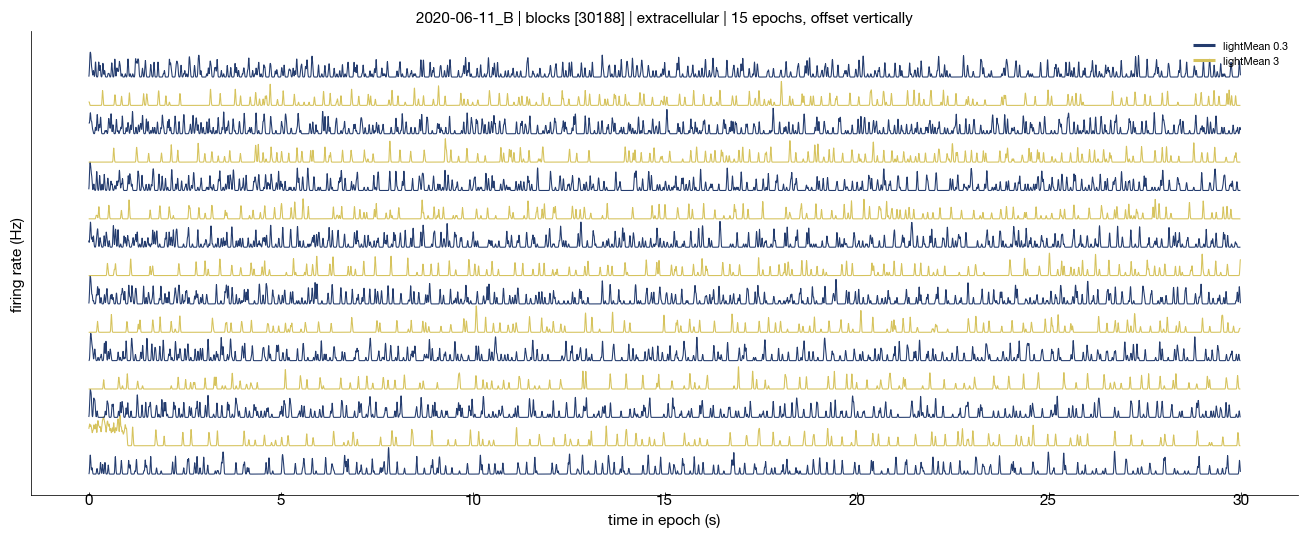

In [4]:
CELL_INDEX = 2
REC_TYPE = 'extracellular'   # 'extracellular', 'exc' or 'inh'
SKIP_SECONDS = 2.0           # drop the settling period at the start of each epoch
MAX_EPOCHS = None              # None for every epoch
DOWNSAMPLE = 10              # 10 kHz -> 1 kHz, by block average

row = protocol_cells[protocol_cells.cell_index.eq(CELL_INDEX)].iloc[0]
print(f'{row.exp_name} | {row.cell_label} ({row.cell_type}) | {row.led} | '
      f'lightMean {row.light_means} | contrast {row.light_contrast} | '
      f'{row.stim_seconds} s')
print(f'epochs: {row.n_extracellular} extracellular, {row.n_exc} exc, {row.n_inh} inh')

EXP_NAME, BLOCK_IDS, rec_type = vmn.cell_blocks(
    protocol_cells, CELL_INDEX, rec_type=REC_TYPE, modes=block_modes)
print(f'\nfitting {rec_type} blocks {BLOCK_IDS}')

trace_figure = vmn.plot_traces(EXP_NAME, BLOCK_IDS, rec_type, max_epochs=MAX_EPOCHS)

  lightMean 0.3: 8 epochs (6 train / 2 test) | r²=0.776 held out, 0.795 in sample | time-to-peak 26 ms
  lightMean 3: 7 epochs (5 train / 2 test) | r²=0.619 held out, 0.642 in sample | time-to-peak 25 ms

<ConditionAnalysis 2020-06-11_B blocks=[30188] | extracellular | lightMean 0.3, 3>


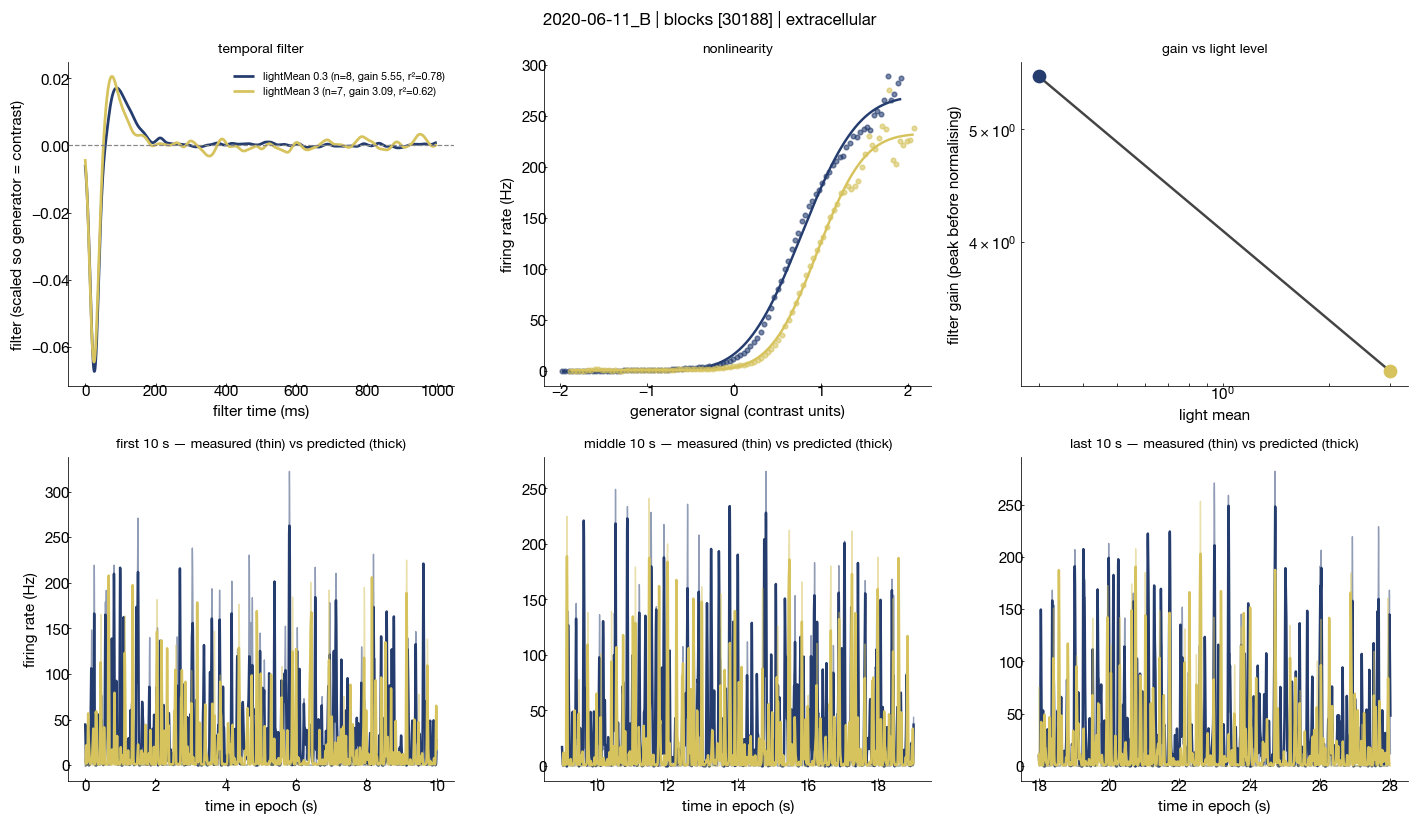

In [5]:
analysis = vmn.analyze_condition(
    EXP_NAME, BLOCK_IDS, rec_type=rec_type, skip_seconds=SKIP_SECONDS,
    downsample=DOWNSAMPLE, max_epochs=MAX_EPOCHS, verbose=True)
print(f'\n{analysis}')

condition_figure = vmn.plot_condition(analysis)

### 2a. The adaptation, as two numbers

**Time-to-peak** — a cell adapted to a dimmer mean integrates for longer.

**`gain`** — the factor the filter was divided by to bring the generator signal's `sigma/mean`
down to the stimulus's own contrast. It is the amplitude the filter contributed, so it is the
cell's gain: a dim-adapted cell produces more response per unit contrast, and its filter is
correspondingly taller in the figure above.

`r2` is held out, `r2_train` in sample, and `nl_r2` is the sigmoid's fit to the binned
nonlinearity points — **not** model performance, shown only so it is not mistaken for it.

In [ ]:
rows = []
for mean_level in analysis.light_means:
    model = analysis.ln_model[mean_level]
    rows.append({
        'lightMean': mean_level,
        'n_epochs': analysis.n_epochs[mean_level],
        'n_train': model.n_train, 'n_test': model.n_test,
        'r2': model.r2, 'r2_train': model.r2_train, 'nl_r2': model.nl_r2,
        'time_to_peak_ms': model.time_to_peak_ms,
        'gain': model.filter_gain,
        'biphasic_index': model.biphasic_index,
    })
summary = pd.DataFrame(rows)
display(summary.round(3))

if len(summary) > 1:
    dim, bright = summary.iloc[0], summary.iloc[-1]
    ratio = dim.gain / bright.gain
    print(f'lightMean {dim.lightMean:g} -> {bright.lightMean:g}  '
          f'({bright.lightMean / dim.lightMean:.0f}x brighter):')
    print(f'  time-to-peak {dim.time_to_peak_ms:.0f} -> {bright.time_to_peak_ms:.0f} ms')
    print(f'  gain         {dim.gain:.3g} -> {bright.gain:.3g} '
          f'({ratio:.1f}x lower at the brighter mean)' if ratio > 1 else
          f'  gain         {dim.gain:.3g} -> {bright.gain:.3g} '
          f'({1 / ratio:.1f}x higher at the brighter mean)')

## 3. LED light level

The LED's own neutral density filters set the light level. A `FilterWheel` NDF is real — the
wheel exists on the rig — but it is **not in the LED's path**, so it must not be added to this
stimulus's attenuation. `led_attenuation` returns it separately with `wheel_ignored` set, rather
than dropping it silently, because the same metadata is correct for a Stage protocol and wrong
here.

A filter with no entry in the rig's LED table leaves `optical_density` blank and is named in
`unknown_tokens`, so an unknown filter cannot masquerade as no attenuation.

In [ ]:
light_rows = []
for (exp_name, led), group in protocol_blocks.groupby(['exp_name', 'led'], dropna=False):
    entry = vmn.led_attenuation(group.iloc[0])
    entry['n_blocks'] = len(group)
    light_rows.append(entry)
light = pd.DataFrame(light_rows)

sc.scroll_table(
    light[['exp_name', 'rig', 'led', 'led_ndfs', 'optical_density', 'attenuation',
           'wheel_tokens_ignored', 'unknown_tokens', 'n_blocks']].round(4),
    height=340, num_cols=('optical_density', 'attenuation', 'n_blocks'))

unresolved = light[light.unknown_tokens.ne('')]
print(f'{len(light)} experiment x LED combinations | '
      f'{int(light.wheel_ignored.sum())} list an FW filter that is not in the LED path '
      f'(stripped, and named in wheel_tokens_ignored)')
if len(unresolved):
    print(f'{len(unresolved)} with filters missing from the rig LED table: '
          f'{sorted(set(unresolved.unknown_tokens))}')

## 4. The saved MATLAB summary, for comparison

`matlabSummary/rodVariableMeanNoise.mat` holds the 53 cells the MATLAB analysis was run on,
with its own fitted LN models. It is **not** an input to anything above — the analysis here runs
from the recordings. It is kept so the Python population summary can be compared against the
MATLAB's once there is one.

One thing to know when matching them up: the saved `expDate` is **two days early**, across the
board. `vmn.resolve_roster_files` applies that correction and confirms each cell by label
(case-sensitively) and type; `vmn.SAVED_DATE_OFFSET_DAYS` is the constant. That is only needed
for the comparison, so it is not run here.

In [ ]:
roster = vmn.load_summary(show=True)

sc.scroll_table(
    roster[['index', 'exp_date', 'cell_label', 'cell_type', 'rec_type',
            'epoch_len_ms', 'tau_low', 'tau_high', 'is_example']].round(2),
    height=300, num_cols=('index', 'epoch_len_ms', 'tau_low', 'tau_high'))

print(f'\nsaved dates are {vmn.SAVED_DATE_OFFSET_DAYS} days early; '
      f'vmn.resolve_roster_files() corrects and confirms them when needed.')